# **Assignment 2**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')

/tmp/ipython-input-3421444000.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')


1.The Internet sales of Adventure Works by year of each Country Region

    Year CountryRegion   SalesAmount
0   2010            AU  2.090978e+04
1   2010            CA  3.578270e+03
2   2010            FR  3.399990e+03
3   2010            GB  6.990982e+02
4   2010            US  1.483390e+04
5   2011            AU  2.563732e+06
6   2011            CA  5.715718e+05
7   2011            DE  5.205002e+05
8   2011            FR  4.108453e+05
9   2011            GB  5.505912e+05
10  2011            US  2.458285e+06
11  2012            AU  2.128407e+06
12  2012            CA  3.076045e+05
13  2012            DE  6.086580e+05
14  2012            FR  6.480655e+05
15  2012            GB  7.127010e+05
16  2012            US  1.437049e+06
17  2013            AU  4.339443e+06
18  2013            CA  1.085633e+06
19  2013            DE  1.761876e+06
20  2013            FR  1.578512e+06
21  2013            GB  2.124007e+06
22  2013            US  5.462079e+06
23  2014            AU  8.507720e+03
24  2014            CA  9.457620e+03
25  2014            DE  3.277830e+03
2

<Figure size 1000x600 with 0 Axes>

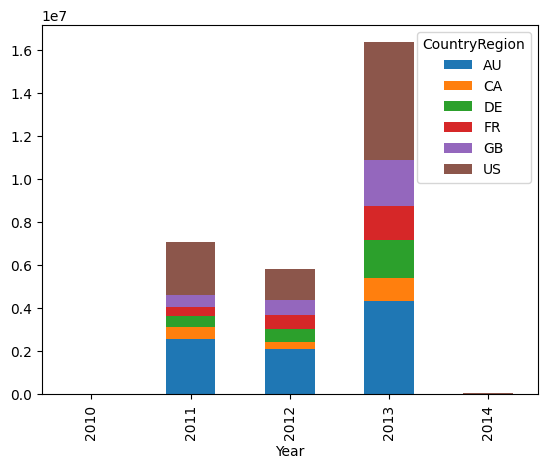

In [5]:
#category by year
sales['OrderDate'] = pd.to_datetime(sales['OrderDateKey'].astype(str))
Year = sales.OrderDate.dt.year
sales['Year'] = sales['OrderDate'].dt.year
#category by country region
sales['CountryRegion'] = sales['CountryRegionCode']
#sum the amount of internet sales
sales_summary = sales.groupby(['Year', 'CountryRegion'])['SalesAmount'].sum().reset_index()
print(sales_summary)
plt.figure(figsize=(10,6))
pivot_table = sales_summary.pivot(index='Year', columns='CountryRegion', values='SalesAmount')
pivot_table.plot(kind='bar', stacked=True)
plt.show()


2.Generate summary satistics including min, max, and sd for Yearly Income, Genderby Country Regions

In [19]:
yearly_income = sales.groupby(['CountryRegion','Gender'])['YearlyIncome'].sum().reset_index()
(yearly_income).describe()

,YearlyIncome
count,1.200000e+01
mean,3.005558e+08
std,2.159190e+08
min,1.094800e+08
25%,1.348975e+08
50%,2.047200e+08
75%,4.388125e+08
max,6.978300e+08


<Axes: xlabel='CountryRegion', ylabel='SalesAmount'>

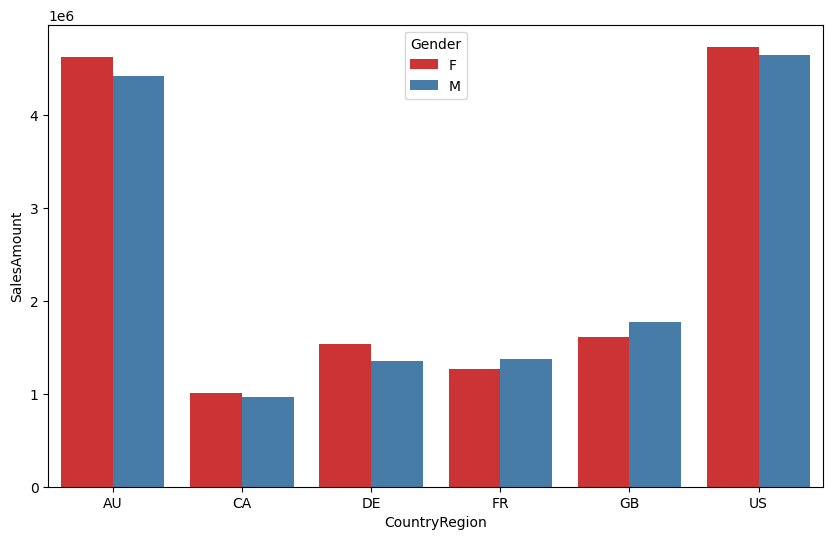

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(data=sales_summary_gender,
    x='CountryRegion',
    y='SalesAmount',
    hue='Gender',
    palette='Set1',
    errorbar=None)

3.Average price of the product category that generates the most sales

In [26]:
product_sales = sales.groupby(['ProductKey'])['SalesAmount'].sum().reset_index()
product_sales = product_sales.sort_values(by='SalesAmount', ascending=False)
product_sales



,ProductKey,SalesAmount
10,312,1205876.99
8,310,1202298.72
11,313,1080637.54
12,314,1055589.65
9,311,1005493.87
...,...,...
106,530,7425.12
92,480,7307.39
96,484,7218.60
93,481,2679.02


/tmp/ipython-input-1289082735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_products,


<Axes: xlabel='ProductKey', ylabel='SalesAmount'>

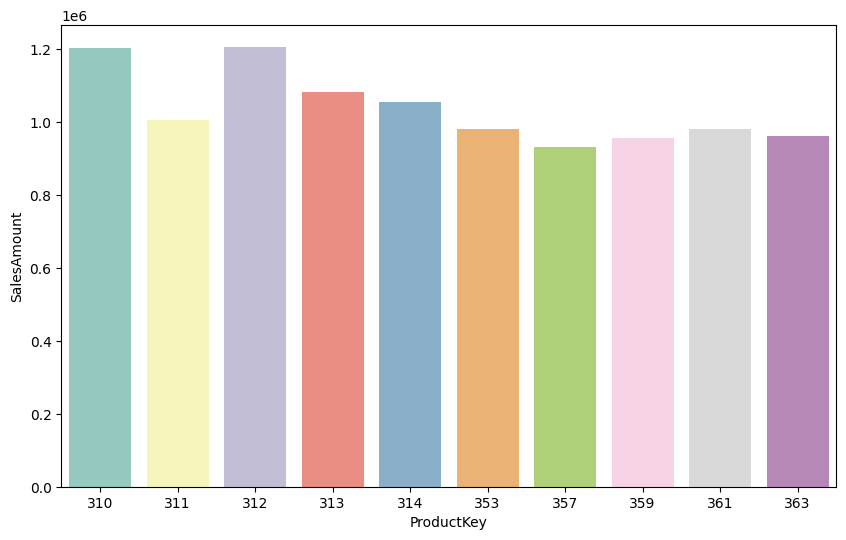

In [33]:
plt.figure(figsize=(10,6))
top10_products = product_sales.head(10)
sns.barplot(data=top10_products,
    x='ProductKey',
    y='SalesAmount',
    palette='Set3',
    errorbar=None)

4.Owning a home make a difference in sales?

In [39]:
home = sales.groupby(['HouseOwnerFlag'])['SalesAmount'].sum().reset_index()
home

,HouseOwnerFlag,SalesAmount
0,0,8.973327e+06
1,1,2.038535e+07


/tmp/ipython-input-1980000559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=home,


<Axes: xlabel='HouseOwnerFlag', ylabel='SalesAmount'>

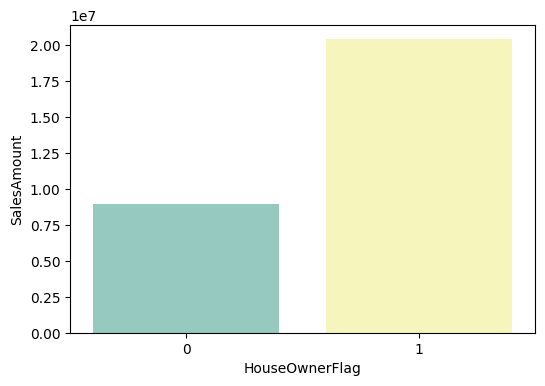

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(data=home,
    x='HouseOwnerFlag',
    y='SalesAmount',
    palette='Set3',
    errorbar=None)

In [45]:
#average amount of owning a house
home_avg = sales.groupby(['HouseOwnerFlag'])['SalesAmount'].mean().reset_index()
home_avg

,HouseOwnerFlag,SalesAmount
0,0,479.882744
1,1,488.869033
